# Lab: Split data & Model Creation (vectorizer, TFIDF)

## Objectives
- Load and split the emotion dataset into train/val/test sets
- Apply text cleaning and preprocessing (lowercase, punctuation removal, stop-word removal, lemmatization)
- Vectorize text using TF-IDF (fit on train only)
- Build a Sequential Dense Neural Network for 6-class emotion classification
- Evaluate with Loss/Accuracy curves, Classification Report, and Confusion Matrix
- Predict on unseen custom sentences

## 1. Train-Test split of data

For this lab, the dataset has been provided for you so you can directly load our train.txt, val.txt and test.txt files.

In [1]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\r_kar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\r_kar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\r_kar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Result: The first step - Load data correctly

In [3]:
def load_data(filepath):
    texts, labels = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if ';' in line:
                text, label = line.rsplit(';', 1)
                texts.append(text)
                labels.append(label)
    return pd.DataFrame({'text': texts, 'label': labels})

train_df = load_data('data/train.txt')
val_df   = load_data('data/val.txt')
test_df  = load_data('data/test.txt')

print('Train:', train_df.shape)
print('Val:  ', val_df.shape)
print('Test: ', test_df.shape)
train_df.head()

Train: (16000, 2)
Val:   (2000, 2)
Test:  (2000, 2)


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
# Check label distribution
print(train_df['label'].value_counts())

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


### Result: The second step - Clean and preprocessing

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenise
    tokens = text.split()
    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

train_df['clean'] = train_df['text'].apply(clean_text)
val_df['clean']   = val_df['text'].apply(clean_text)
test_df['clean']  = test_df['text'].apply(clean_text)

train_df[['text','clean']].head(3)

,text,clean
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong


### Result: The third step - Vectorize / Create embeddings for your text

**Pitfall**: We ONLY call `fit_transform` on the training set. Val and Test are only `transform`-ed.

**Overfitting fix**: Reduced `max_features` from 10000 to 5000 to cut down on noise in the feature space.

In [6]:
# Reduced from 10000 -> 5000 to reduce noise and help with overfitting
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train_df['clean']).toarray()   # fit + transform on train
X_val   = tfidf.transform(val_df['clean']).toarray()         # transform only
X_test  = tfidf.transform(test_df['clean']).toarray()        # transform only

print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (16000, 5000)
X_val shape:   (2000, 5000)
X_test shape:  (2000, 5000)


### Setting up & Label Encoding

We use a fixed alphabetical mapping so class 0 is always the same emotion across all splits.

In [7]:
# Sorted alphabetically to guarantee consistent mapping across splits
emotion_classes = sorted(train_df['label'].unique())
print('Classes:', emotion_classes)

label_to_idx = {label: idx for idx, label in enumerate(emotion_classes)}
print('Mapping:', label_to_idx)

y_train_int = train_df['label'].map(label_to_idx).values
y_val_int   = val_df['label'].map(label_to_idx).values
y_test_int  = test_df['label'].map(label_to_idx).values

num_classes = len(emotion_classes)

# One-hot encode for the model
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val   = to_categorical(y_val_int,   num_classes=num_classes)
y_test  = to_categorical(y_test_int,  num_classes=num_classes)

print('y_train shape:', y_train.shape)

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Mapping: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
y_train shape: (16000, 6)


### The fourth step - Split the data

The data is already pre-split into train / val / test files — no further splitting needed.

In [8]:
print('Train samples:', X_train.shape[0])
print('Val samples:  ', X_val.shape[0])
print('Test samples: ', X_test.shape[0])

Train samples: 16000
Val samples:   2000
Test samples:  2000


### The Fifth step - Building our Sequential model

A simple fully-connected network with `softmax` output for multi-class classification.

**Overfitting fix**: Reduced layer sizes (256->128, 128->64) and increased Dropout from 0.3 to 0.5.
Higher dropout means more neurons are randomly switched off during each training step, forcing the network to learn more robust and generalised patterns instead of memorising the training data.

In [9]:
# Smaller architecture + higher dropout to combat overfitting
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

c:\Users\r_kar\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,774 (2.47 MB)

 Trainable params: 648,774 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Finally fit the model

**Overfitting fix**: `EarlyStopping` monitors `val_loss` and halts training the moment it stops improving for 3 consecutive epochs (`patience=3`). Setting `restore_best_weights=True` means the model automatically rewinds to the checkpoint with the lowest val_loss — not the overfit final epoch.

In [11]:
# Stop training when val_loss stops improving for 3 consecutive epochs.
# restore_best_weights=True rewinds the model back to its best checkpoint.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,           # high ceiling — early stopping will cut this short
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4723 - loss: 1.3779 - val_accuracy: 0.7490 - val_loss: 0.8111
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8084 - loss: 0.5929 - val_accuracy: 0.8840 - val_loss: 0.3832
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9089 - loss: 0.3050 - val_accuracy: 0.8895 - val_loss: 0.3276
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9371 - loss: 0.2092 - val_accuracy: 0.8925 - val_loss: 0.3265
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9534 - loss: 0.1554 - val_accuracy: 0.8905 - val_loss: 0.3414
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9628 - loss: 0.1235 - val_accuracy: 0.8890 - val_loss: 0.3739
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9705 - loss: 0.0973 - val_accuracy: 0.8920 - val_loss: 0.3901

Training stopped at epoch 7


### The Sixth Step: Evaluation

#### Simple Method - plot the curves

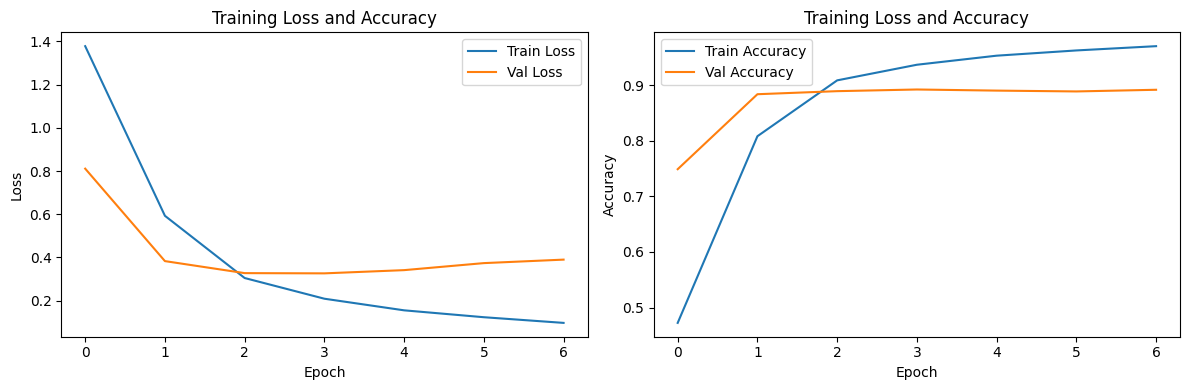

In [12]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

#### Setting Confusion Matrix

In [13]:
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [14]:
cm = confusion_matrix(y_test_int, y_pred)
print(cm)

[[242   7   8   0  18   0]
 [ 12 177   6   0  16  13]
 [  4   4 638  38   7   4]
 [  2   0  33 122   2   0]
 [ 18   6  20   1 536   0]
 [  0   7   8   1   3  47]]


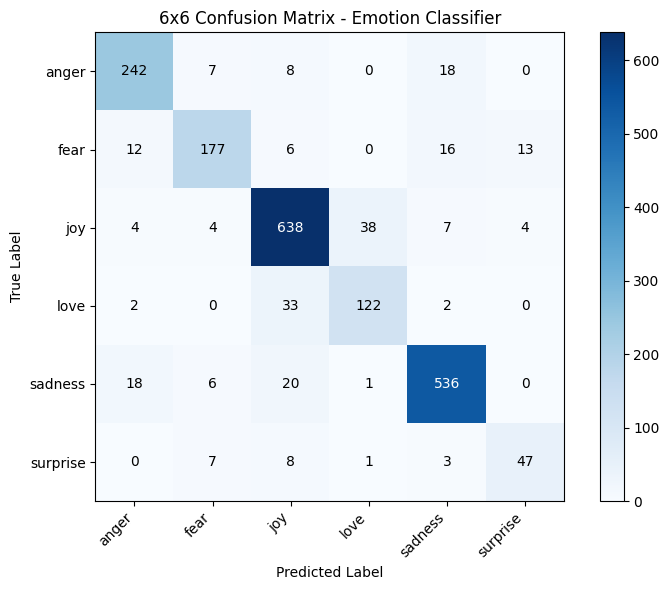

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(emotion_classes, rotation=45, ha='right')
ax.set_yticklabels(emotion_classes)

# Annotate each cell
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('6x6 Confusion Matrix - Emotion Classifier')
plt.tight_layout()
plt.show()

#### Or just using classification report - Inspect this method

In [16]:
print(classification_report(y_test_int, y_pred, target_names=emotion_classes))

              precision    recall  f1-score   support

       anger       0.87      0.88      0.88       275
        fear       0.88      0.79      0.83       224
         joy       0.89      0.92      0.91       695
        love       0.75      0.77      0.76       159
     sadness       0.92      0.92      0.92       581
    surprise       0.73      0.71      0.72        66

    accuracy                           0.88      2000
   macro avg       0.84      0.83      0.84      2000
weighted avg       0.88      0.88      0.88      2000



### Predict on new sentences

In [17]:
def predict_emotion(text):
    """
    Takes a raw text string, cleans and vectorizes it,
    runs it through the trained model, and prints the predicted emotion.
    """
    cleaned    = clean_text(text)
    vectorized = tfidf.transform([cleaned]).toarray()
    pred_probs = model.predict(vectorized, verbose=0)
    pred_idx   = np.argmax(pred_probs, axis=1)[0]
    pred_label = emotion_classes[pred_idx]
    confidence = pred_probs[0][pred_idx]
    print(f'Input     : "{text}"')
    print(f'Predicted : {pred_label}  (confidence: {confidence:.2%})')
    return pred_label

# Try some examples
predict_emotion("I am so incredibly angry right now!")
predict_emotion("I feel so happy and grateful today")
predict_emotion("I am terrified of what might happen next")

Input     : "I am so incredibly angry right now!"
Predicted : anger  (confidence: 93.74%)
Input     : "I feel so happy and grateful today"
Predicted : joy  (confidence: 99.58%)
Input     : "I am terrified of what might happen next"
Predicted : fear  (confidence: 99.47%)


'fear'